# FaceNet — Finetuning on Casia Face Dataset & Evaluating on LFW
**Paper-faithful implementation using Triplet Loss + Semi-Hard Negative Mining**

Pipeline:
1. Install & Imports
2. Paths & Config
3. Dataset — Triplet Builder from Casia Face Dataset
4. Model — InceptionResnetV1 (FaceNet backbone)
5. Triplet Loss (paper eq.)
6. Semi-Hard Negative Mining (paper Section 3.1)
7. Finetuning Loop
8. LFW Evaluation — Accuracy, ROC, AUC

### Dataset Setup on Kaggle

This notebook requires **two datasets** added to your Kaggle notebook:

| Dataset | Purpose | Kaggle Path |
|---|---|---|
| `casia-face-dataset` | Training | `/kaggle/input/datasets/cybersimar08/casia-face-dataset` |
| `lfw-dataset` | LFW test evaluation | `/kaggle/input/datasets/jessicali9530/lfw-dataset` |


## ⚠️ Important Instructions

1. Run the **first cell only**.
2. After it finishes:
   - Restart the kernel and clear all cell outputs
3. Then:
   - Comment out the **first cell**
4. Finally, click **Run All**


## 1. Install Required Packages

Below cell ensures the Kaggle environment uses specific versions of numpy, Pillow and facenet-pytorch to prevent runtime conflicts

In [21]:
import subprocess, sys

pkgs = [
    "numpy==1.26.4",
    "pandas",
    "Pillow==10.3.0",
    "torchvision",
    "facenet-pytorch",
]

subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "--force-reinstall", "--quiet",
] + pkgs)

print('\nAll packages reinstalled successfully.')

## 2. Import required Libraries

In [39]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from facenet_pytorch import InceptionResnetV1, MTCNN

from sklearn.metrics import roc_curve, auc, accuracy_score
import matplotlib.pyplot as plt

# Reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Libraries imported successfully.")
print(f"Random seeds set (42). Processing on device: {DEVICE}")

Libraries imported successfully.
Random seeds set (42). Processing on device: cuda


## 3. Paths & Configurations

In [40]:
CASIA_FACE_ROOT = '/kaggle/input/datasets/cybersimar08/casia-face-dataset'

# ── Test Dataset: LFW ──────────────────────────────────────────────────────
LFW_BASE_CSV  = '/kaggle/input/datasets/jessicali9530/lfw-dataset'
LFW_IMG_BASE  = '/kaggle/input/datasets/jessicali9530/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled'

MATCH_TEST_CSV     = f'{LFW_BASE_CSV}/matchpairsDevTest.csv'
MISMATCH_TEST_CSV  = f'{LFW_BASE_CSV}/mismatchpairsDevTest.csv'

# ── Hyperparameters (paper-faithful) ───────────────────────────────────────
EMBED_DIM   = 128     # FaceNet paper uses 128-d
MARGIN      = 0.2     # paper default alpha
BATCH_SIZE  = 32
EPOCHS      = 20
LR          = 5e-5
PATIENCE    = 3       # early stopping
MIN_DELTA   = 1e-4
IMG_SIZE    = 160     # standard FaceNet input
MIN_IMGS_PER_ID = 2   # minimum images an identity must have to be used

print(f"Configuration loaded. Device: {DEVICE}")
print(f"Train root: {CASIA_FACE_ROOT}")
print(f"LFW test  : {LFW_BASE_CSV}")
print(f"Epochs: {EPOCHS}, Batch Size: {BATCH_SIZE}, Margin: {MARGIN}")

Configuration loaded. Device: cuda
Train root: /kaggle/input/datasets/cybersimar08/casia-face-dataset
LFW test  : /kaggle/input/datasets/jessicali9530/lfw-dataset
Epochs: 20, Batch Size: 32, Margin: 0.2


## 4. Transforms

In [41]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

print("Data augmentations and transforms defined for Train & Test.")

Data augmentations and transforms defined for Train & Test.


## 5. CASIA Face Dataset Scanner

Scans the CASIA Face directory tree and builds an identity → [image paths] mapping.
No CSV is required — the folder structure defines the labels.

In [42]:
def scan_casiaface(root, min_imgs=2):
    """
    Walk the CasiaFace directory and return:
        identity_to_imgs : dict  {identity_name: [abs_path, ...]}

    Skips identities with fewer than `min_imgs` images (can't form a positive pair).
    Supports nested layout:  root/split/identity/img.jpg
    and flat layout:         root/identity/img.jpg
    """
    IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}
    identity_to_imgs = defaultdict(list)

    for dirpath, dirnames, filenames in os.walk(root):
        imgs = [os.path.join(dirpath, f)
                for f in filenames
                if os.path.splitext(f)[1].lower() in IMG_EXTS]
        if not imgs:
            continue
        # Use the immediate parent folder name as the identity label
        identity = os.path.basename(dirpath)
        identity_to_imgs[identity].extend(imgs)

    # Filter identities with too few images
    identity_to_imgs = {
        k: v for k, v in identity_to_imgs.items() if len(v) >= min_imgs
    }

    return identity_to_imgs


print("Scanning Casia Face dataset...")
identity_to_imgs = scan_casiaface(CASIA_FACE_ROOT, min_imgs=MIN_IMGS_PER_ID)
all_identities   = list(identity_to_imgs.keys())
total_images     = sum(len(v) for v in identity_to_imgs.values())

print(f"Identities found : {len(all_identities)}")
print(f"Total images     : {total_images}")
print(f"Avg imgs/identity: {total_images / len(all_identities):.1f}")
print(f"Sample identities: {all_identities[:5]}")

Scanning Casia Face dataset...
Identities found : 200
Total images     : 20197
Avg imgs/identity: 101.0
Sample identities: ['000187', '000413', '000444', '000521', '000256']


## 6. Triplet Dataset — Casia Face

Builds (Anchor, Positive, Negative) triplets directly from the folder structure:
- **Anchor & Positive** → two different images of the *same* identity
- **Negative** → one image of a *different* identity

In [26]:
class CasiaFaceTripletDataset(Dataset):
    """
    Builds triplets from Casia Face using folder-based identity labels.

    Strategy:
      - For each identity with >= 2 images, randomly sample an
        (anchor, positive) pair from that identity.
      - Randomly pick a negative from any OTHER identity.

    `num_triplets_per_id` triplets are constructed per identity so
    all identities contribute equally regardless of image count.
    """
    def __init__(self, identity_to_imgs, transform=None, num_triplets_per_id=10):
        self.transform = transform
        self.identities = list(identity_to_imgs.keys())
        self.id2imgs    = identity_to_imgs
        self.triplets   = []

        for identity in self.identities:
            pos_pool = self.id2imgs[identity]
            neg_ids  = [i for i in self.identities if i != identity]

            for _ in range(num_triplets_per_id):
                # Sample anchor & positive (must be different images)
                if len(pos_pool) < 2:
                    continue
                anchor_p, positive_p = random.sample(pos_pool, 2)

                # Sample negative from a random different identity
                neg_id   = random.choice(neg_ids)
                negative_p = random.choice(self.id2imgs[neg_id])

                self.triplets.append((anchor_p, positive_p, negative_p))

        # Shuffle so identities are interleaved across batches
        random.shuffle(self.triplets)
        print(f'Total triplets built: {len(self.triplets)}')

    def __len__(self):
        return len(self.triplets)

    def __getitem__(self, idx):
        anchor_p, positive_p, negative_p = self.triplets[idx]
        anchor   = self._load(anchor_p)
        positive = self._load(positive_p)
        negative = self._load(negative_p)
        return anchor, positive, negative

    def _load(self, path):
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img


# Build the training dataset
train_dataset = CasiaFaceTripletDataset(
    identity_to_imgs,
    transform=train_transform,
    num_triplets_per_id=10
)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)
print(f"Train loader ready: {len(train_dataset)} triplets, {len(train_loader)} batches/epoch")

Total triplets built: 2000
Train loader ready: 2000 triplets, 63 batches/epoch


## 7. Model — FaceNet (Paper Faithful)
- Backbone: InceptionResnetV1 pretrained on VGGFace2
- Output: 128-d L2-normalized embedding (as in paper)

In [43]:
class FaceNetModel(nn.Module):
    """
    FaceNet paper-faithful model:
    - InceptionResnetV1 backbone pretrained on VGGFace2
    - Projects to 128-d embedding (paper default)
    - L2 normalizes output (paper eq. 1)
    """
    def __init__(self, embed_dim=128, freeze_early=True):
        super().__init__()

        # Pretrained FaceNet backbone
        self.backbone = InceptionResnetV1(pretrained='vggface2')

        # Freeze early layers — they already know faces
        # Only finetune the last block + projection
        if freeze_early:
            for name, param in self.backbone.named_parameters():
                if ('block35' not in name and 'block17' not in name and
                    'block8' not in name and 'last_linear' not in name
                    and 'last_bn' not in name):
                    param.requires_grad = False

        # Project 512-d backbone output → 128-d (paper uses 128)
        self.projection = nn.Linear(512, embed_dim)

    def forward(self, x):
        features   = self.backbone(x)           # [B, 512]
        embeddings = self.projection(features)  # [B, 128]
        embeddings = F.normalize(embeddings, p=2, dim=1)  # L2 normalize — paper eq. 1
        return embeddings


model = FaceNetModel(embed_dim=EMBED_DIM, freeze_early=True).to(DEVICE)

# Count trainable params
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')

Trainable params: 2,584,960 / 27,975,991


## 8. Triplet Loss — Paper Equation
$$\mathcal{L} = \sum_{i}^{N} \left[ \| f(A^i) - f(P^i) \|_2^2 - \| f(A^i) - f(N^i) \|_2^2 + \alpha \right]_+$$

In [44]:
class TripletLoss(nn.Module):
    """
    FaceNet paper Triplet Loss (Section 2).
    Uses squared L2 distance — NOT cosine similarity.
    margin alpha = 0.2 (paper default)
    """
    def __init__(self, margin=0.2):
        super().__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        dist_ap = torch.sum((anchor - positive) ** 2, dim=1)  # ||f(A) - f(P)||²
        dist_an = torch.sum((anchor - negative) ** 2, dim=1)  # ||f(A) - f(N)||²
        loss    = F.relu(dist_ap - dist_an + self.margin)     # max(·, 0)
        return loss.mean()


criterion = TripletLoss(margin=MARGIN)
print(f"Triplet Loss initialized with margin alpha = {MARGIN}")

Triplet Loss initialized with margin alpha = 0.2


## 9. Semi-Hard Negative Mining — Paper Section 3.1
Select negatives that satisfy:
$$\| f(A) - f(P) \|_2^2 < \| f(A) - f(N) \|_2^2 < \| f(A) - f(P) \|_2^2 + \alpha$$

In [45]:
def semi_hard_negative_mining(emb_a, emb_p, emb_n, margin=0.2):
    """
    Paper Section 3.1 — Semi-hard negative mining.

    For each anchor, find negatives that are:
      - Farther than the positive  (harder than easy)
      - Still within margin alpha  (not too hard)

    If no semi-hard negative exists → fallback to hardest negative.

    Args:
        emb_a: anchor embeddings   [B, D]
        emb_p: positive embeddings [B, D]
        emb_n: negative pool       [B, D]
        margin: alpha from paper

    Returns:
        selected negatives [B, D]
    """
    dist_ap = torch.sum((emb_a - emb_p) ** 2, dim=1, keepdim=True)  # [B, 1]
    dist_an = torch.cdist(emb_a, emb_n) ** 2                         # [B, B]

    # Semi-hard zone: dist_ap < dist_an < dist_ap + margin
    semi_hard_mask = (dist_an > dist_ap) & (dist_an < dist_ap + margin)

    selected = []
    for i in range(emb_a.size(0)):
        valid = semi_hard_mask[i].nonzero(as_tuple=True)[0]
        if len(valid) > 0:
            # Closest semi-hard negative
            idx = valid[torch.argmin(dist_an[i][valid])]
        else:
            # Fallback: hardest negative (closest overall)
            idx = torch.argmin(dist_an[i])
        selected.append(emb_n[idx])

    return torch.stack(selected)  # [B, D]

print("Semi-Hard Negative Mining function (Paper Section 3.1) compiled.")

Semi-Hard Negative Mining function (Paper Section 3.1) compiled.


## 10. Finetuning Loop

In [49]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

history          = []
best_loss        = float('inf')
no_improve_count = 0

for epoch in range(EPOCHS):
    model.train()
    total_loss  = 0.0
    total_steps = 0

    for anchor_imgs, positive_imgs, negative_imgs in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}'):
        anchor_imgs   = anchor_imgs.to(DEVICE)
        positive_imgs = positive_imgs.to(DEVICE)
        negative_imgs = negative_imgs.to(DEVICE)

        # Forward pass
        emb_a = model(anchor_imgs)
        emb_p = model(positive_imgs)

        # Semi-hard mining on negative pool (no grad for mining step)
        with torch.no_grad():
            emb_n_pool = model(negative_imgs)

        emb_n = semi_hard_negative_mining(emb_a.detach(), emb_p.detach(), emb_n_pool, margin=MARGIN)

        # Compute triplet loss
        loss = criterion(emb_a, emb_p, emb_n)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss  += loss.item()
        total_steps += 1

    scheduler.step()
    avg_loss = total_loss / total_steps
    history.append(avg_loss)
    print(f'Epoch [{epoch+1}/{EPOCHS}]  Triplet Loss: {avg_loss:.4f}  LR: {scheduler.get_last_lr()[0]:.2e}')

    # ── Early Stopping ──────────────────────────────────────────────────
    if avg_loss < best_loss - MIN_DELTA:
        best_loss        = avg_loss
        no_improve_count = 0
        torch.save(model.state_dict(), 'facenet_casiaface_best.pth')
        print(f'  ✅ Best model saved (loss: {best_loss:.4f})')
    else:
        no_improve_count += 1
        print(f'  ⚠️  No improvement ({no_improve_count}/{PATIENCE})')
        if no_improve_count >= PATIENCE:
            print(f'\nEarly stopping triggered at epoch {epoch+1}')
            break

print(f'\nTraining complete. Best loss: {best_loss:.4f}')

Epoch 1/20: 100%|██████████| 63/63 [00:12<00:00,  5.02it/s]


Epoch [1/20]  Triplet Loss: 0.0844  LR: 5.00e-05
  ✅ Best model saved (loss: 0.0844)


Epoch 2/20: 100%|██████████| 63/63 [00:11<00:00,  5.40it/s]


Epoch [2/20]  Triplet Loss: 0.0936  LR: 5.00e-05
  ⚠️  No improvement (1/3)


Epoch 3/20: 100%|██████████| 63/63 [00:11<00:00,  5.39it/s]


Epoch [3/20]  Triplet Loss: 0.0974  LR: 5.00e-05
  ⚠️  No improvement (2/3)


Epoch 4/20: 100%|██████████| 63/63 [00:11<00:00,  5.41it/s]

Epoch [4/20]  Triplet Loss: 0.1004  LR: 5.00e-05
  ⚠️  No improvement (3/3)

Early stopping triggered at epoch 4

Training complete. Best loss: 0.0844


## 11. Plot Training Loss

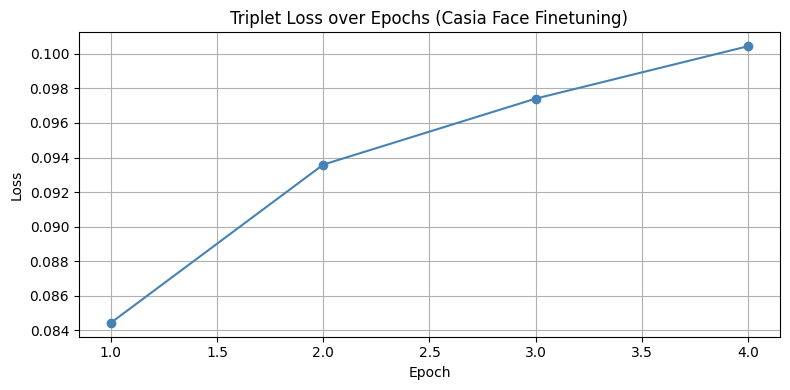

In [50]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(history) + 1), history, marker='o', color='steelblue')
plt.title('Triplet Loss over Epochs (Casia Face Finetuning)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.tight_layout()
plt.show()

## 12. Load Best Checkpoint for Evaluation

In [51]:
# Load the best saved checkpoint before running LFW evaluation
checkpoint_path = 'facenet_casiaface_best.pth'
if os.path.exists(checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    print(f'✅ Best checkpoint loaded from: {checkpoint_path}')
else:
    print('⚠️  No checkpoint found — evaluating with weights from last epoch.')

✅ Best checkpoint loaded from: facenet_casiaface_best.pth


## 13. LFW Evaluation Dataset

Builds (img1, img2, label) pairs from matchpairsDevTest + mismatchpairsDevTest

In [52]:
def lfw_img_path(name, num):
    """
    Builds LFW image path from person name and image number.
    Format: {LFW_IMG_BASE}/{name}/{name}_{num:04d}.jpg
    Example: Tyler_Hamilton, 2 → .../Tyler_Hamilton/Tyler_Hamilton_0002.jpg
    """
    return os.path.join(LFW_IMG_BASE, name, f'{name}_{int(num):04d}.jpg')


class LFWPairDataset(Dataset):
    """
    Evaluation dataset — returns image pairs with labels.
    label=1 → same person, label=0 → different person
    """
    def __init__(self, match_csv, mismatch_csv, transform=None):
        self.transform = transform
        self.pairs     = []

        # Same-person pairs (label=1)
        match_df = pd.read_csv(match_csv)
        for _, row in match_df.iterrows():
            p1 = lfw_img_path(row['name'], row['imagenum1'])
            p2 = lfw_img_path(row['name'], row['imagenum2'])
            if os.path.exists(p1) and os.path.exists(p2):
                self.pairs.append((p1, p2, 1))

        # Different-person pairs (label=0)
        mismatch_df = pd.read_csv(mismatch_csv)
        for _, row in mismatch_df.iterrows():
            p1 = lfw_img_path(row['name'],   row['imagenum1'])
            p2 = lfw_img_path(row['name.1'], row['imagenum2'])
            if os.path.exists(p1) and os.path.exists(p2):
                self.pairs.append((p1, p2, 0))

        print(f'Test pairs: {len(self.pairs)} '
              f'({sum(l for _,_,l in self.pairs)} same, '
              f'{sum(1-l for _,_,l in self.pairs)} diff)')

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        p1, p2, label = self.pairs[idx]
        img1 = self._load(p1)
        img2 = self._load(p2)
        return img1, img2, torch.tensor(label, dtype=torch.float32)

    def _load(self, path):
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img


test_dataset = LFWPairDataset(MATCH_TEST_CSV, MISMATCH_TEST_CSV, transform=test_transform)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)


Test pairs: 1000 (500 same, 500 diff)


## 14. Evaluation — L2 Distance + Threshold
Paper uses L2 distance. Lower distance = more similar.

In [53]:
model.eval()

all_distances = []
all_labels    = []

with torch.no_grad():
    for img1, img2, labels in tqdm(test_loader, desc='Evaluating on LFW'):
        img1, img2 = img1.to(DEVICE), img2.to(DEVICE)

        emb1 = model(img1)   # [B, 128]
        emb2 = model(img2)   # [B, 128]

        # L2 distance (paper metric)
        dist = torch.sum((emb1 - emb2) ** 2, dim=1).sqrt()  # [B]

        all_distances.extend(dist.cpu().numpy())
        all_labels.extend(labels.numpy())

all_distances = np.array(all_distances)
all_labels    = np.array(all_labels)

print(f'Evaluated {len(all_labels)} LFW pairs')
print(f'Distance range: [{all_distances.min():.4f}, {all_distances.max():.4f}]')

Evaluating on LFW: 100%|██████████| 16/16 [00:03<00:00,  4.57it/s]

Evaluated 1000 LFW pairs
Distance range: [0.1227, 1.1031]


## 15. Threshold Tuning + Accuracy

Best Threshold : 0.60
Best Accuracy  : 94.60%


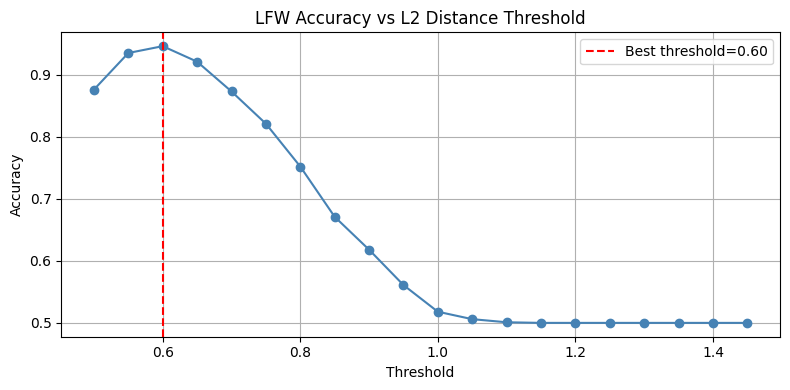

In [54]:
# Try multiple thresholds and find best accuracy
thresholds = np.arange(0.5, 1.5, 0.05)
accuracies = []

for thresh in thresholds:
    # Predict: distance < threshold → same person (label=1)
    preds = (all_distances < thresh).astype(int)
    acc   = accuracy_score(all_labels, preds)
    accuracies.append(acc)

best_idx      = np.argmax(accuracies)
best_thresh   = thresholds[best_idx]
best_accuracy = accuracies[best_idx]

print(f'Best Threshold : {best_thresh:.2f}')
print(f'Best Accuracy  : {best_accuracy*100:.2f}%')

# Plot accuracy vs threshold
plt.figure(figsize=(8, 4))
plt.plot(thresholds, accuracies, marker='o', color='steelblue')
plt.axvline(best_thresh, color='red', linestyle='--', label=f'Best threshold={best_thresh:.2f}')
plt.title('LFW Accuracy vs L2 Distance Threshold')
plt.xlabel('Threshold')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 16. ROC Curve + AUC

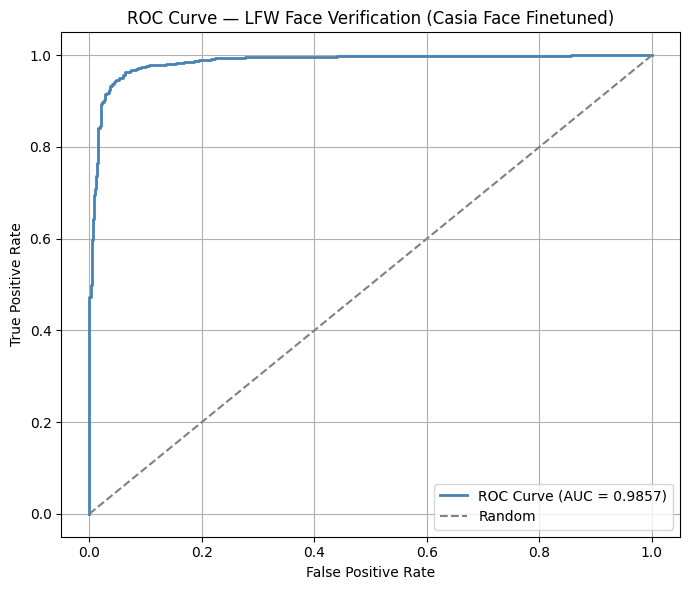

AUC: 0.9857


In [55]:
# For ROC: similarity = -distance (higher = more similar = more likely same person)
similarity_scores = -all_distances

fpr, tpr, _ = roc_curve(all_labels, similarity_scores)
roc_auc     = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — LFW Face Verification (Casia Face Finetuned)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f'AUC: {roc_auc:.4f}')

## 17. Visualize Sample Predictions

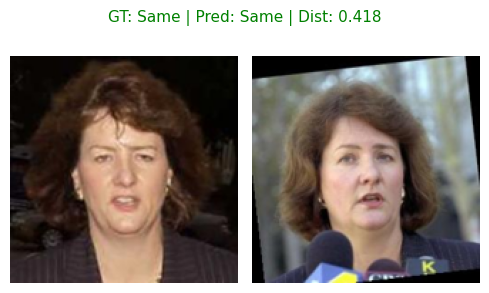

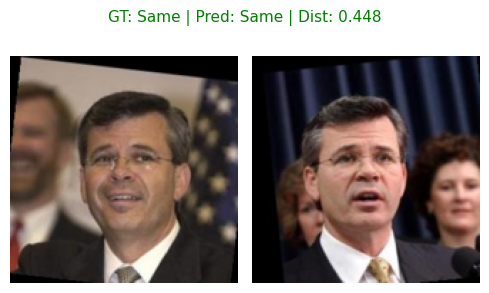

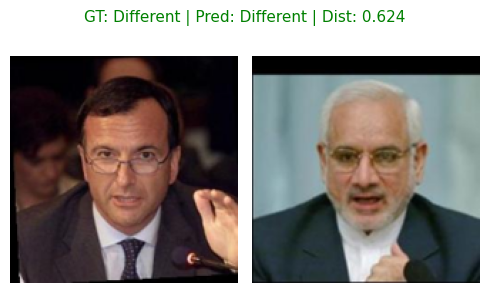

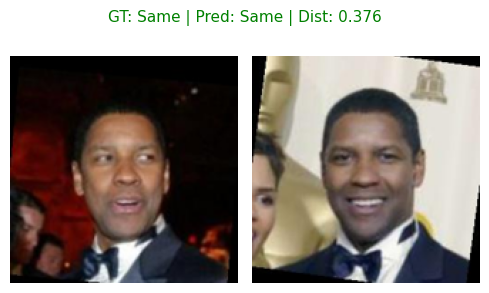

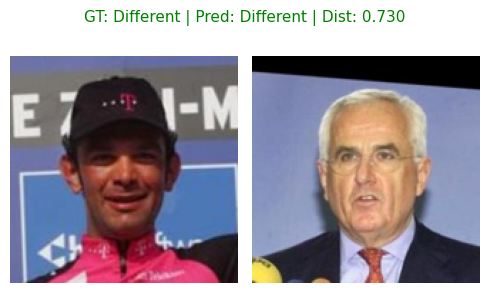

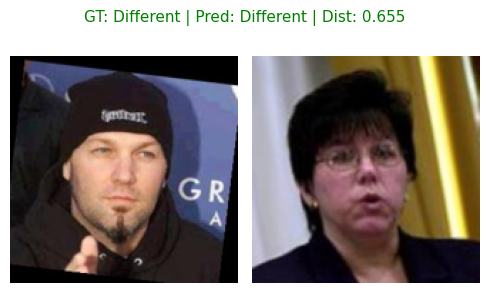

In [57]:
def show_pair(path1, path2, label, pred_label, distance):
    fig, axes = plt.subplots(1, 2, figsize=(5, 3))
    for ax, p in zip(axes, [path1, path2]):
        ax.imshow(Image.open(p).resize((160, 160)))
        ax.axis('off')
    gt  = 'Same' if label == 1 else 'Different'
    pr  = 'Same' if pred_label == 1 else 'Different'
    col = 'green' if label == pred_label else 'red'
    plt.suptitle(f'GT: {gt} | Pred: {pr} | Dist: {distance:.3f}', color=col, fontsize=11)
    plt.tight_layout()
    plt.show()


# Show 6 random LFW test samples
indices = random.sample(range(len(test_dataset)), 6)
preds   = (all_distances < best_thresh).astype(int)

for idx in indices:
    p1, p2, label = test_dataset.pairs[idx]
    show_pair(p1, p2, int(label), preds[idx], all_distances[idx])

## 18. Final Summary

In [59]:
final_preds = (all_distances < best_thresh).astype(int)

tp = np.sum((final_preds == 1) & (all_labels == 1))
tn = np.sum((final_preds == 0) & (all_labels == 0))
fp = np.sum((final_preds == 1) & (all_labels == 0))
fn = np.sum((final_preds == 0) & (all_labels == 1))

precision = tp / (tp + fp + 1e-8)
recall    = tp / (tp + fn + 1e-8)
f1        = 2 * precision * recall / (precision + recall + 1e-8)

print('=' * 45)
print('   LFW EVALUATION SUMMARY')
print('   (Finetuned on CASIA Face)')
print('=' * 45)
print(f'  Accuracy  : {best_accuracy*100:.2f}%')
print(f'  AUC       : {roc_auc:.4f}')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  F1 Score  : {f1:.4f}')
print(f'  Threshold : {best_thresh:.2f}')
print(f'  TP:{tp}  TN:{tn}  FP:{fp}  FN:{fn}')
print('=' * 45)

   LFW EVALUATION SUMMARY
   (Finetuned on CASIA Face)
  Accuracy  : 94.60%
  AUC       : 0.9857
  Precision : 0.9407
  Recall    : 0.9520
  F1 Score  : 0.9463
  Threshold : 0.60
  TP:476  TN:470  FP:30  FN:24
